# RFM 分析

本 Notebook 用于对 `inventor_rfm.csv` 数据进行 RFM 分析，包括：
1. 加载数据
2. 分析 R, F, M 指标的分布
3. 根据分布情况定义 RFM 评分标准
4. 计算 RFM 分数
5. 进行客户分群
6. 保存结果

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 设置绘图样式
sns.set(style="whitegrid")

## 1. 加载数据

In [86]:
data_file = r'./inventor_rfm.csv' # 使用相对路径
output_file = r'./inventor_rfm_segmented.csv'
output_dir = os.path.dirname(output_file)

try:
    rfm_df = pd.read_csv(data_file)
    print(f"Data loaded successfully from {data_file}")
    print("\nData preview:")
    display(rfm_df.head())
    print("\nData Info:")
    rfm_df.info()
except FileNotFoundError:
    print(f"Error: File not found at {data_file}")
    rfm_df = None
except Exception as e:
    print(f"An error occurred while loading data: {e}")
    rfm_df = None

Data loaded successfully from ./inventor_rfm.csv

Data preview:


,ID,Inventor,Recency,Frequency,Monetary
0,1,*非凡,1417,4,0.434474
1,2,A-F·尤什达,49,1,0.388256
2,3,A-S·盖耶,346,1,0.311097
3,4,A-V·S·皮蓬,941,1,0.489123
4,5,A.A.D.M.佩雷拉,2012,1,0.326212



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34535 entries, 0 to 34534
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         34535 non-null  int64  
 1   Inventor   34535 non-null  object 
 2   Recency    34535 non-null  int64  
 3   Frequency  34535 non-null  int64  
 4   Monetary   34535 non-null  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 1.3+ MB


## 2. 分析 R, F, M 指标的分布


Descriptive Statistics for R, F, M:


,Recency,Frequency,Monetary
count,34535.000000,34535.000000,34535.000000
mean,981.942870,1.898798,0.479344
std,965.401675,3.804533,0.162424
min,0.000000,1.000000,0.278845
25%,308.000000,1.000000,0.354525
50%,745.000000,1.000000,0.424313
75%,1379.000000,2.000000,0.548238
max,13715.000000,299.000000,0.999893


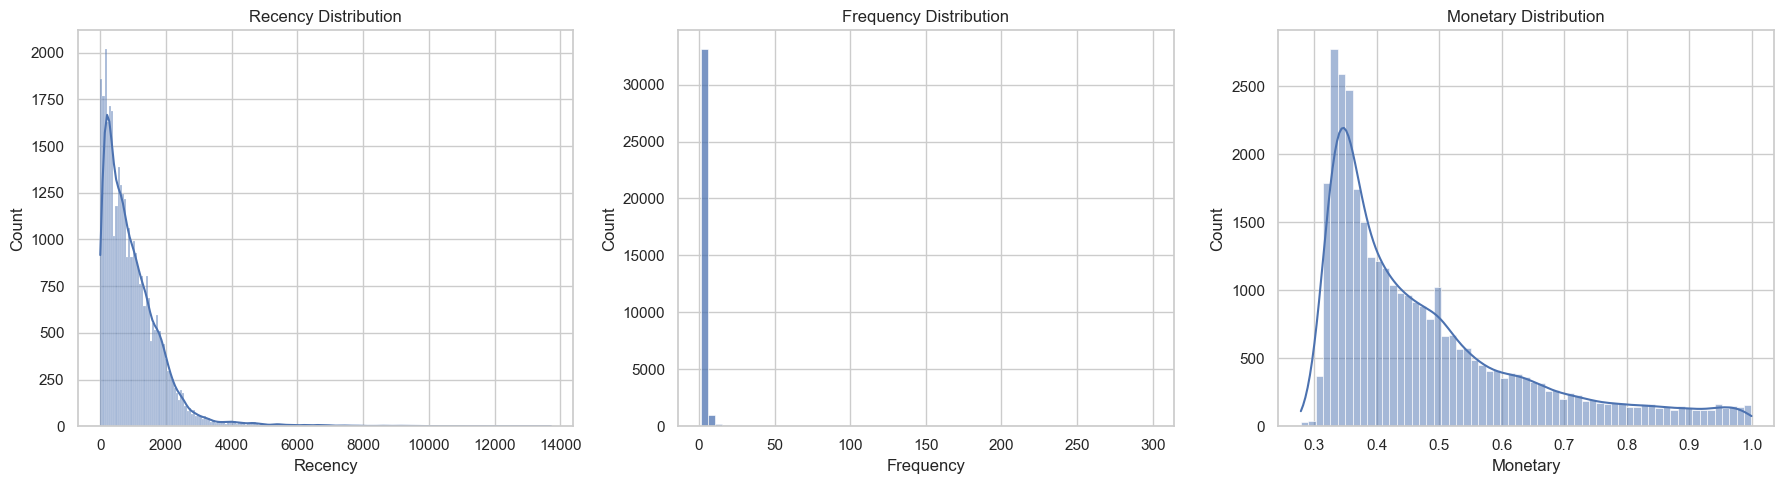

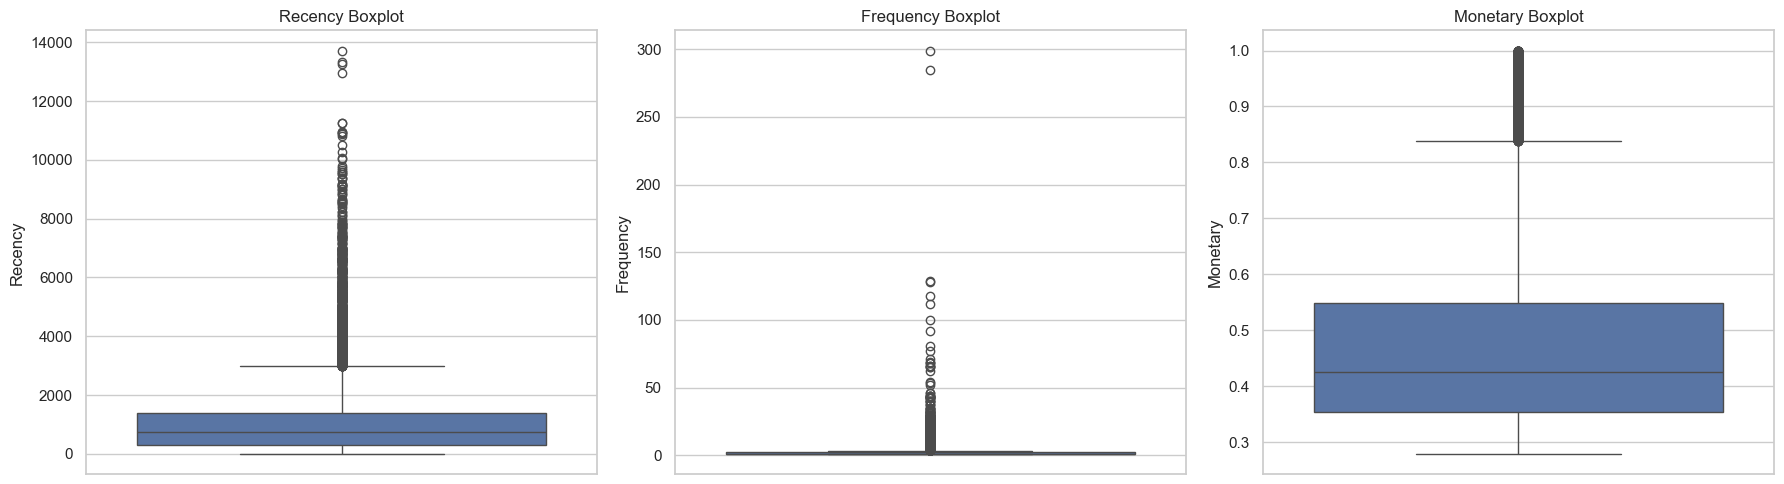

In [87]:
if rfm_df is not None:
    print("\nDescriptive Statistics for R, F, M:")
    display(rfm_df[['Recency', 'Frequency', 'Monetary']].describe())

    # 绘制分布图
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    sns.histplot(rfm_df['Recency'], kde=True)
    plt.title('Recency Distribution')

    plt.subplot(1, 3, 2)
    # Frequency 通常是右偏的，可能需要对数变换或关注低频区域
    sns.histplot(rfm_df['Frequency'], kde=False, bins=max(10, rfm_df['Frequency'].nunique())) # 调整bins
    plt.title('Frequency Distribution')
    # plt.xscale('log') # 如果分布非常偏斜，可以考虑对数刻度

    plt.subplot(1, 3, 3)
    sns.histplot(rfm_df['Monetary'], kde=True)
    plt.title('Monetary Distribution')

    plt.tight_layout()
    plt.show()

    # 绘制箱线图查看异常值
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    sns.boxplot(y=rfm_df['Recency'])
    plt.title('Recency Boxplot')

    plt.subplot(1, 3, 2)
    sns.boxplot(y=rfm_df['Frequency'])
    plt.title('Frequency Boxplot')

    plt.subplot(1, 3, 3)
    sns.boxplot(y=rfm_df['Monetary'])
    plt.title('Monetary Boxplot')

    plt.tight_layout()
    plt.show()

## 3. 定义 RFM 评分标准 (6级)

根据上面的分布图和描述性统计，我们选择**分位数法**进行评分，并将数据等分为 **6** 份。

*   **Recency (R)**: 值越小越好。得分 6 -> 最近；得分 1 -> 最久。
*   **Frequency (F)**: 值越大越好。得分 6 -> 频率最高；得分 1 -> 频率最低。
*   **Monetary (M)**: 值越大越好。得分 6 -> 价值最高；得分 1 -> 价值最低。

In [88]:
if rfm_df is not None:
    # 定义分位数点 (分为6个等级)
    quantiles = rfm_df[['Recency', 'Frequency', 'Monetary']].quantile(q=[1/6, 2/6, 3/6, 4/6, 5/6]).to_dict()
    print("Quantiles for Scoring (6 Levels):")
    display(pd.DataFrame(quantiles))

    # --- R Score --- (值越小越好, 1-6分)
    def r_score(x, quantiles):
        if x <= quantiles['Recency'][1/6]:
            return 6
        elif x <= quantiles['Recency'][2/6]:
            return 5
        elif x <= quantiles['Recency'][3/6]:
            return 4
        elif x <= quantiles['Recency'][4/6]:
            return 3
        elif x <= quantiles['Recency'][5/6]:
            return 2
        else:
            return 1

    # --- F Score & M Score --- (值越大越好, 1-6分)
    def fm_score(x, metric, quantiles):
        if x <= quantiles[metric][1/6]:
            return 1
        elif x <= quantiles[metric][2/6]:
            return 2
        elif x <= quantiles[metric][3/6]:
            return 3
        elif x <= quantiles[metric][4/6]:
            return 4
        elif x <= quantiles[metric][5/6]:
            return 5
        else:
            return 6

    # 应用评分函数
    rfm_df['R_Score'] = rfm_df['Recency'].apply(r_score, args=(quantiles,))
    rfm_df['F_Score'] = rfm_df['Frequency'].apply(fm_score, args=('Frequency', quantiles,))
    rfm_df['M_Score'] = rfm_df['Monetary'].apply(fm_score, args=('Monetary', quantiles,))

    print("\nRFM Scores Calculated (1-6):")
    display(rfm_df[['ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score']].head())

Quantiles for Scoring (6 Levels):


,Recency,Frequency,Monetary
0.166667,206.0,1.0,0.341160
0.333333,448.0,1.0,0.371175
0.500000,745.0,1.0,0.424313
0.666667,1130.0,1.0,0.499965
0.833333,1690.0,2.0,0.629941



RFM Scores Calculated (1-6):


,ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,1,1417,4,0.434474,2,6,4
1,2,49,1,0.388256,6,1,3
2,3,346,1,0.311097,5,1,1
3,4,941,1,0.489123,3,1,4
4,5,2012,1,0.326212,1,1,1


## 4. 计算 RFM 总分 (可选)

In [89]:
if rfm_df is not None:
    # 计算总分 (可选)
    rfm_df['RFM_Total_Score'] = rfm_df['R_Score'] + rfm_df['F_Score'] + rfm_df['M_Score']

    print("\nRFM Total Score Calculated:")
    display(rfm_df[['ID', 'RFM_Total_Score']].head())


RFM Total Score Calculated:


,ID,RFM_Total_Score
0,1,12
1,2,10
2,3,7
3,4,8
4,5,3


## 5. 人才分群 (基于 RFM 三维 - 6级评分)

根据 RFM 分数进行人才分群。我们将基于 R, F, M 三个维度的评分高低进行划分。

评分标准 (基于6级评分):
*   **高**: R/F/M 评分 > 3 (即 4, 5 或 6)
*   **低**: R/F/M 评分 <= 3 (即 1, 2 或 3)

人才类别定义 (R高=近期活跃, F高=频率高, M高=价值高):
*   **顶尖创新者**: R高, F高, M高
*   **权威贡献者**: R低, F高, M高
*   **突破领先者**: R高, F低, M高
*   **沉睡价值者**: R低, F低, M高
*   **活跃潜力者**: R高, F高, M低
*   **稳定产出者**: R低, F高, M低
*   **偶发创新者**: R高, F低, M低
*   **边缘参与者**: R低, F低, M低

In [90]:
if rfm_df is not None:
    # --- 设置字体以支持中文显示 ---
    plt.rcParams['font.sans-serif'] = ['SimHei'] # 或 'Microsoft YaHei', 'Arial Unicode MS' 等支持中文的字体
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号'-'显示为方块的问题
    # ---------------------------------

    # 定义评分阈值 (大于此值为高)
    r_threshold = 3
    f_threshold = 3
    m_threshold = 3

    # 定义分群函数
    def assign_segment(row, r_thresh, f_thresh, m_thresh):
        r_high = row['R_Score'] > r_thresh
        f_high = row['F_Score'] > f_thresh
        m_high = row['M_Score'] > m_thresh

        if r_high and f_high and m_high:
            return '顶尖创新者'
        elif not r_high and f_high and m_high:
            return '权威贡献者'
        elif r_high and not f_high and m_high:
            return '​​突破领先者'
        elif not r_high and not f_high and m_high:
            return '活跃潜力者'
        elif r_high and f_high and not m_high:
            return '沉睡价值者​​'
        elif not r_high and f_high and not m_high:
            return '稳定产出者'
        elif r_high and not f_high and not m_high:
            return '偶发创新者'
        elif not r_high and not f_high and not m_high:
            return '边缘参与者'
        else:
            return '未分类' # 理论上不应出现

    # 应用分群函数
    rfm_df['Segment'] = rfm_df.apply(assign_segment, args=(r_threshold, f_threshold, m_threshold), axis=1)

    print("\nTalent Segmentation (RFM 3D - 6 Levels):")
    display(rfm_df[['ID', 'R_Score', 'F_Score', 'M_Score', 'Segment']].head())

    print("\nSegment Distribution:")
    segment_counts = rfm_df['Segment'].value_counts()
    display(segment_counts)


Talent Segmentation (RFM 3D - 6 Levels):


,ID,R_Score,F_Score,M_Score,Segment
0,1,2,6,4,权威贡献者
1,2,6,1,3,偶发创新者
2,3,5,1,1,偶发创新者
3,4,3,1,4,活跃潜力者
4,5,1,1,1,边缘参与者



Segment Distribution:


Segment
边缘参与者      7155
偶发创新者      6069
活跃潜力者      5573
​​突破领先者    4871
顶尖创新者      4146
权威贡献者      2677
沉睡价值者​​    2186
稳定产出者      1858
Name: count, dtype: int64

## 6. 3D 可视化人才分布

In [91]:
import plotly.express as px

if rfm_df is not None:
    fig = px.scatter_3d(rfm_df,
                        x='R_Score',
                        y='F_Score',
                        z='M_Score',
                        color='Segment', # 按更新后的分群结果着色
                        hover_name='Inventor', # 鼠标悬停显示发明人姓名
                         # 悬停显示额外信息
                        title='发明人RFM评分3D散点图',
                        labels={'R_Score': 'R Score',
                                'F_Score': 'F Score',
                                'M_Score': 'M Score'},
                        category_orders={'Segment': ['顶尖创新者', '权威贡献者', '​​突破领先者', '活跃潜力者', '沉睡价值者​​', '稳定产出者', '偶发创新者', '边缘参与者']}
                       )
    fig.show()

## 7. 保存结果

In [92]:
if rfm_df is not None:
    try:
        # 确保输出目录存在
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
            print(f"Created output directory: {output_dir}")

        # 保存带有 RFM 分数和分群的完整数据
        # 确保移除不再需要的列
        columns_to_save = ['ID', 'Inventor', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Total_Score', 'Segment']
        rfm_df_to_save = rfm_df[columns_to_save]
        rfm_df_to_save.to_csv(output_file, index=False, encoding='utf-8-sig') # 使用 utf-8-sig 保证 Excel 兼容性
        print(f"\nRFM analysis complete. Results saved to {output_file}")
    except Exception as e:
        print(f"An error occurred while saving data: {e}")


RFM analysis complete. Results saved to ./inventor_rfm_segmented.csv
